
--- Maintenance Optimization Results ---
Optimal Action Threshold: RUL <= 10 cycles
Minimum Fleet Operational Cost: $543,650.00
Unplanned In-Flight Failures: 0


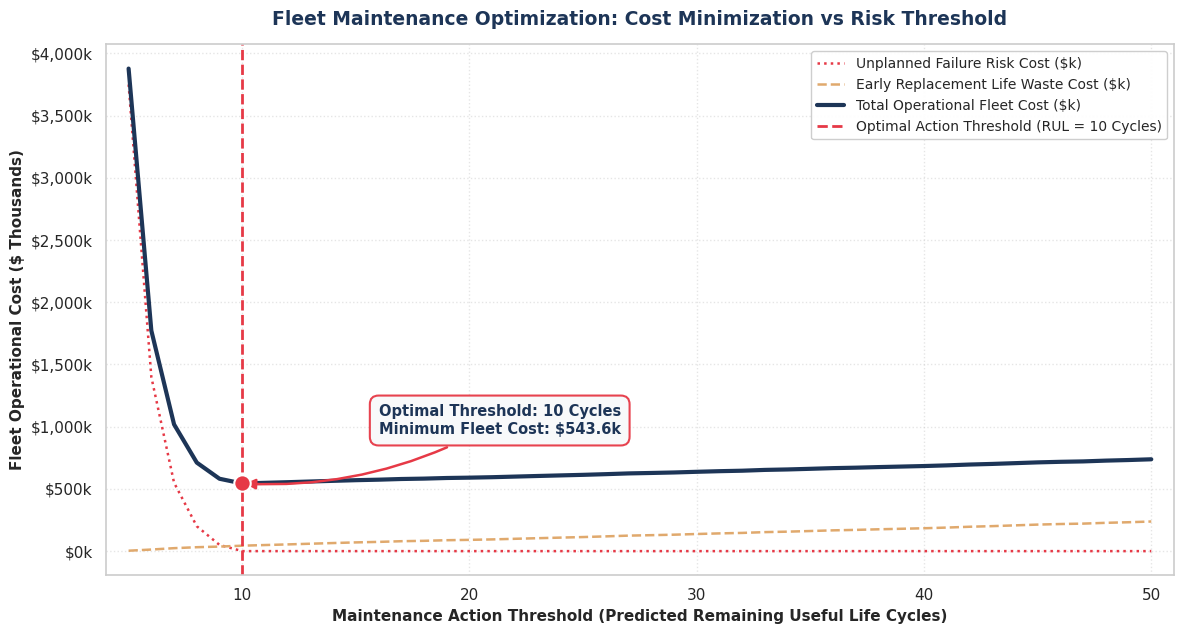


--- Operational Fleet Status Summary (Cycles per Risk Zone) ---
Risk_Zone
NORMAL: Operational                       19201
CRITICAL: Immediate Grounding Required     1430


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.model_selection import GroupKFold

# Global Plot Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.sans-serif": "DejaVu Sans", 
    "font.family": "sans-serif",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 1.2
})

# Base Directory Setup
BASE_DIR = "***/data_analysis_portfolio/project-2"
DATA_PATH = os.path.join(BASE_DIR, "data/processed/cmapss_engineered.csv")
FIGURES_DIR = os.path.join(BASE_DIR, "reports/figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. Load Engineered Dataset & Model Setup
# ---------------------------------------------------------
df = pd.read_csv(DATA_PATH)

cols_to_drop = ["setting_3"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

RUL_CAP = 125
df["RUL_clipped"] = df["RUL"].clip(upper=RUL_CAP)

meta_cols = ["unit_nr", "time_cycles", "RUL", "RUL_clipped"]
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols].values
y = df["RUL_clipped"].values
groups = df["unit_nr"].values

# Generate Out-of-Fold Predictions for Unbiased Threshold Evaluation
gkf = GroupKFold(n_splits=5)
df["preds"] = np.zeros(len(df))

model = LGBMRegressor(
    n_estimators=150,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

for train_idx, val_idx in gkf.split(X, y, groups):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val = X[val_idx]
    
    model.fit(X_train, y_train)
    df.loc[val_idx, "preds"] = model.predict(X_val)

# ---------------------------------------------------------
# 2. Cost Matrix Definition
# ---------------------------------------------------------
# Business Cost Parameters ($)
COST_PREVENTIVE = 5_000   # Planned maintenance (part replacement + scheduled labor)
COST_UNPLANNED  = 50_000  # In-flight failure / unplanned unscheduled grounding
COST_EARLY_PER_CYCLE = 50 # Waste of remaining engine life per unused cycle

# ---------------------------------------------------------
# 3. Decision Threshold Optimization Loop
# ---------------------------------------------------------
threshold_range = range(5, 51, 1)
cost_simulation_results = []

for threshold in threshold_range:
    # Trigger maintenance the first time predicted RUL <= threshold per unit
    df["maintenance_flag"] = df["preds"] <= threshold
    
    # Filter for first trigger per unit
    triggered_units = df[df["maintenance_flag"]].groupby("unit_nr").first().reset_index()
    
    # Engine units that never triggered maintenance before actual failure
    untriggered_unit_ids = set(df["unit_nr"].unique()) - set(triggered_units["unit_nr"].unique())
    
    # Costs for triggered units
    triggered_units["true_RUL_at_trigger"] = triggered_units["RUL"]
    
    # Late Interventions vs Successful
    late_interventions = (triggered_units["true_RUL_at_trigger"] == 0).sum()
    successful_interventions = (triggered_units["true_RUL_at_trigger"] > 0).sum()
    
    # Cycles wasted by pulling engine out early
    wasted_cycles = triggered_units["true_RUL_at_trigger"].sum()
    
    # Untriggered engines failed outright
    unplanned_failures = len(untriggered_unit_ids) + late_interventions
    
    preventive_cost = successful_interventions * COST_PREVENTIVE
    unplanned_cost = unplanned_failures * COST_UNPLANNED
    waste_cost = wasted_cycles * COST_EARLY_PER_CYCLE
    total_cost = preventive_cost + unplanned_cost + waste_cost
    
    cost_simulation_results.append({
        "Threshold": threshold,
        "Total_Cost": total_cost,
        "Unplanned_Cost": unplanned_cost,
        "Waste_Cost": waste_cost,
        "Preventive_Cost": preventive_cost,
        "Unplanned_Failures": unplanned_failures,
        "Successful_Maintenance": successful_interventions,
        "Wasted_Cycles": wasted_cycles
    })

sim_df = pd.DataFrame(cost_simulation_results)

# Optimal Threshold Identification
optimal_row = sim_df.loc[sim_df["Total_Cost"].idxmin()]
optimal_threshold = int(optimal_row["Threshold"])
min_cost = optimal_row["Total_Cost"]

print(f"\n--- Maintenance Optimization Results ---")
print(f"Optimal Action Threshold: RUL <= {optimal_threshold} cycles")
print(f"Minimum Fleet Operational Cost: ${min_cost:,.2f}")
print(f"Unplanned In-Flight Failures: {int(optimal_row['Unplanned_Failures'])}")

# ---------------------------------------------------------
# 4. Publication-Ready Cost Curve & Risk Breakdown Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6.5))

# Plot Individual Cost Drivers
ax.plot(
    sim_df["Threshold"],
    sim_df["Unplanned_Cost"] / 1000,
    color="#E63946",
    linestyle=":",
    linewidth=1.8,
    label="Unplanned Failure Risk Cost ($k)",
)

ax.plot(
    sim_df["Threshold"],
    sim_df["Waste_Cost"] / 1000,
    color="#E0A96D",
    linestyle="--",
    linewidth=1.8,
    label="Early Replacement Life Waste Cost ($k)",
)

# Main Fleet Cost Curve
ax.plot(
    sim_df["Threshold"],
    sim_df["Total_Cost"] / 1000,
    color="#1D3557",
    linewidth=3.0,
    label="Total Operational Fleet Cost ($k)",
)

# Optimal Threshold Vertical Line
ax.axvline(
    x=optimal_threshold,
    color="#E63946",
    linestyle="--",
    linewidth=2.0,
    label=f"Optimal Action Threshold (RUL = {optimal_threshold} Cycles)",
)

# Minimum Cost Marker Point
ax.scatter(
    [optimal_threshold],
    [min_cost / 1000],
    color="#E63946",
    edgecolor="white",
    linewidth=1.5,
    s=140,
    zorder=6,
)

# Enhanced Callout Box
ax.annotate(
    f"Optimal Threshold: {optimal_threshold} Cycles\nMinimum Fleet Cost: ${min_cost/1e3:,.1f}k",
    xy=(optimal_threshold, min_cost / 1000),
    xytext=(optimal_threshold + 6, (min_cost / 1000) + 400),
    arrowprops=dict(
        arrowstyle="-|>",
        color="#E63946",
        connectionstyle="arc3,rad=-0.15",
        linewidth=1.8,
        mutation_scale=15
    ),
    fontsize=10.5,
    fontweight="bold",
    color="#1D3557",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#F8F9FA",
        edgecolor="#E63946",
        linewidth=1.5,
        alpha=0.95
    ),
)

# Titles and Axis Labels
ax.set_title(
    "Fleet Maintenance Optimization: Cost Minimization vs Risk Threshold",
    fontsize=13.5,
    fontweight="bold",
    pad=14,
    color="#1D3557"
)
ax.set_xlabel("Maintenance Action Threshold (Predicted Remaining Useful Life Cycles)", fontsize=11, fontweight="bold")
ax.set_ylabel("Fleet Operational Cost ($ Thousands)", fontsize=11, fontweight="bold")

# Y-Axis Formatting ($k)
ax.yaxis.set_major_formatter("${x:,.0f}k")
ax.set_xlim(sim_df["Threshold"].min() - 1, sim_df["Threshold"].max() + 1)

# Grid & Legend Styling
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cccccc", framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "operational_cost_impact.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# ---------------------------------------------------------
# 5. Maintenance Risk Matrix & Anomaly Threshold Flags
# ---------------------------------------------------------
def assign_risk_zone(pred_rul):
    if pred_rul <= 15:
        return "CRITICAL: Immediate Grounding Required"
    elif pred_rul <= optimal_threshold:
        return "WARNING: Schedule Maintenance"
    else:
        return "NORMAL: Operational"

df["Risk_Zone"] = df["preds"].apply(assign_risk_zone)

print("\n--- Operational Fleet Status Summary (Cycles per Risk Zone) ---")
print(df["Risk_Zone"].value_counts().to_string())